# 🔬 Milestone 2: Advanced Data Analysis & Feature Engineering

## 🎯 Objective
1. **Advanced Feature Engineering:** Create impactful features (Salary Bands, Experience Levels) to help the model learn complex patterns.
2. **Advanced Visualizations:** Plot these new features against attrition.
3. **Statistical Hypothesis Testing:** Prove relationships mathematically using T-Tests and Chi-Square tests.
4. **Feature Selection (RFE):** Select the absolute best features for our final model.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, chi2_contingency
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

# Set plot style
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

# 1. Load the RAW dataset to perform clean Feature Engineering
df = pd.read_csv('../data/raw/employee_attrition_raw.csv')

# Quick clean (Drop useless columns identified in MS1)
df.drop(columns=['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], inplace=True, errors='ignore')

print(f"Data ready for Advanced Engineering. Shape: {df.shape}")

Data ready for Advanced Engineering. Shape: (1470, 31)


## 🛠️ 1. Advanced Feature Engineering
We will create new features that represent real-world business logic:
* **Annual Income:** `MonthlyIncome * 12`
* **Salary Category:** Grouping income into Low, Medium, High.
* **Experience Level:** Grouping total working years into Junior, Mid, Senior, Expert.
* **Income Per Year of Experience:** How much they earn relative to their experience.

In [2]:
# 1. Annual Income
df['AnnualIncome'] = df['MonthlyIncome'] * 12

# 2. Salary Category (Using qcut to ensure balanced groups based on percentiles)
df['SalaryCategory'] = pd.qcut(df['MonthlyIncome'], q=3, labels=['Low', 'Medium', 'High'])

# 3. Experience Level (Based on Total Working Years)
df['ExperienceLevel'] = pd.cut(df['TotalWorkingYears'], 
                               bins=[-1, 3, 8, 15, 50], 
                               labels=['Junior', 'Mid', 'Senior', 'Expert'])

# 4. Income Per Year of Experience (+1 to avoid division by zero)
df['IncomePerYearExp'] = df['MonthlyIncome'] / (df['TotalWorkingYears'] + 1)

print("✅ Advanced features created successfully!")
display(df[['MonthlyIncome', 'SalaryCategory', 'TotalWorkingYears', 'ExperienceLevel', 'IncomePerYearExp']].head())

✅ Advanced features created successfully!


,MonthlyIncome,SalaryCategory,TotalWorkingYears,ExperienceLevel,IncomePerYearExp
0,5993,Medium,8,Mid,665.888889
1,5130,Medium,10,Senior,466.363636
2,2090,Low,7,Mid,261.250000
3,2909,Low,8,Mid,323.222222
4,3468,Low,6,Mid,495.428571


## 📊 2. Advanced Visualizations
Let's visually analyze how our newly engineered features impact Attrition.

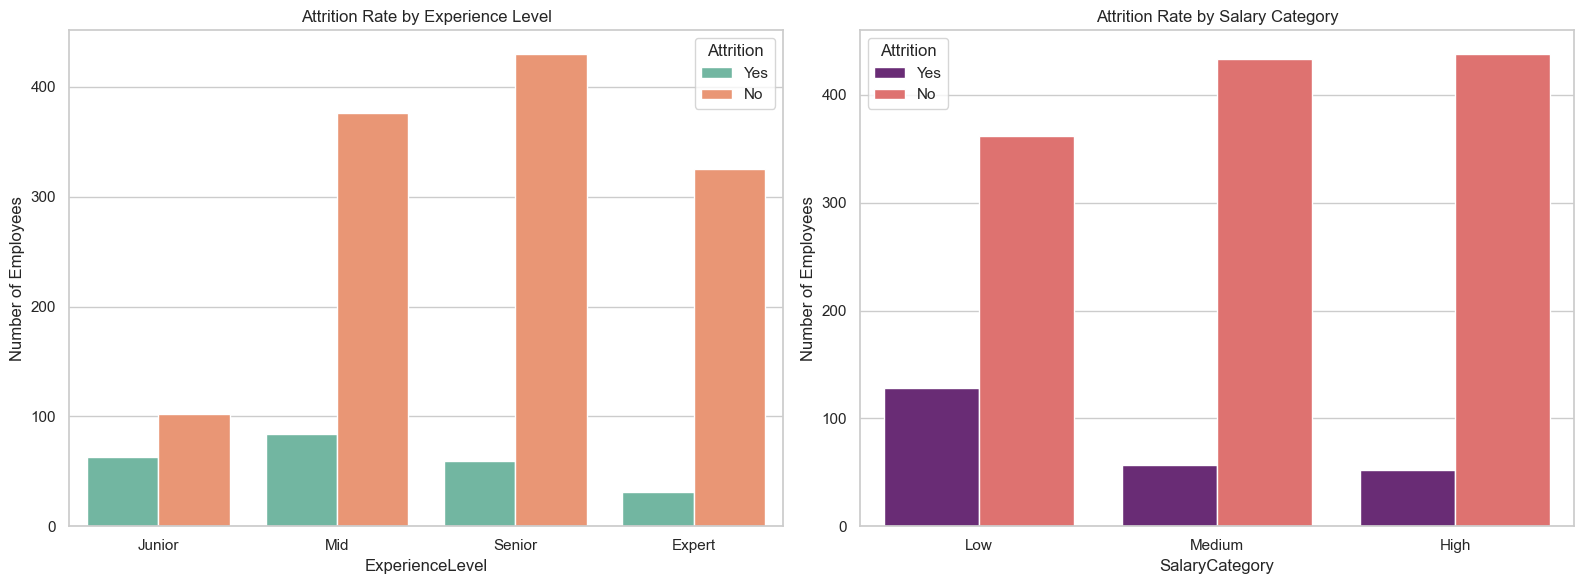

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Experience Level vs Attrition
sns.countplot(data=df, x='ExperienceLevel', hue='Attrition', palette='Set2', ax=axes[0])
axes[0].set_title('Attrition Rate by Experience Level')
axes[0].set_ylabel('Number of Employees')

# Plot 2: Salary Category vs Attrition
sns.countplot(data=df, x='SalaryCategory', hue='Attrition', palette='magma', ax=axes[1])
axes[1].set_title('Attrition Rate by Salary Category')
axes[1].set_ylabel('Number of Employees')

plt.tight_layout()
plt.show()

💡 **Insights from New Features:**
* **Experience:** `Junior` employees have a significantly higher attrition rate compared to Seniors or Experts.
* **Salary:** Employees in the `Low` salary category are the most likely to leave the company.

## 🧮 3. Statistical Analysis (Hypothesis Testing)
We will prove our visual insights using numbers.
* **T-Test:** Does `IncomePerYearExp` significantly differ between those who leave and stay?
* **Chi-Square:** Is there a significant dependency between `SalaryCategory` and `Attrition`?

In [4]:
print("--- Statistical Test 1: T-Test (Income Per Year of Experience) ---")
group_left = df[df['Attrition'] == 'Yes']['IncomePerYearExp']
group_stayed = df[df['Attrition'] == 'No']['IncomePerYearExp']

t_stat, p_val_t = ttest_ind(group_left, group_stayed)
print(f"P-value: {p_val_t:.4e}")
if p_val_t < 0.05:
    print("Result: SIGNIFICANT. The income relative to experience is mathematically different for those who leave.\n")
else:
    print("Result: NOT SIGNIFICANT.\n")

print("--- Statistical Test 2: Chi-Square (Salary Category vs Attrition) ---")
contingency_table = pd.crosstab(df['SalaryCategory'], df['Attrition'])
chi2, p_val_chi, dof, expected = chi2_contingency(contingency_table)

print(f"P-value: {p_val_chi:.4e}")
if p_val_chi < 0.05:
    print("Result: SIGNIFICANT. Salary Category strongly influences attrition.")
else:
    print("Result: NOT SIGNIFICANT.")

--- Statistical Test 1: T-Test (Income Per Year of Experience) ---
P-value: 1.7482e-04
Result: SIGNIFICANT. The income relative to experience is mathematically different for those who leave.

--- Statistical Test 2: Chi-Square (Salary Category vs Attrition) ---
P-value: 1.4348e-12
Result: SIGNIFICANT. Salary Category strongly influences attrition.


## 🧠 3.5 Complex Feature Interactions (Business Logic)
To give our model a deeper understanding of employee behavior, we will create advanced ratio features:
1. **Age-Company Ratio:** (`YearsAtCompany / Age`) - How much of their life has been spent at this company? High ratio might mean high loyalty.
2. **Role Stability:** (`YearsInCurrentRole / YearsAtCompany`) - Have they been stuck in the same role for their entire tenure?

In [5]:
# 1. Age-Company Ratio (Loyalty Indicator)
df['Age_Company_Ratio'] = df['YearsAtCompany'] / df['Age']

# 2. Role Stability (Stagnation Indicator)
# Adding +1 to denominator to avoid division by zero for new employees
df['Role_Stability'] = df['YearsInCurrentRole'] / (df['YearsAtCompany'] + 1)

print("✅ Complex ratio features created: 'Age_Company_Ratio' & 'Role_Stability'")
display(df[['Age', 'YearsAtCompany', 'Age_Company_Ratio', 'YearsInCurrentRole', 'Role_Stability']].head())

✅ Complex ratio features created: 'Age_Company_Ratio' & 'Role_Stability'


,Age,YearsAtCompany,Age_Company_Ratio,YearsInCurrentRole,Role_Stability
0,41,6,0.146341,4,0.571429
1,49,10,0.204082,7,0.636364
2,37,0,0.000000,0,0.000000
3,33,8,0.242424,7,0.777778
4,27,2,0.074074,2,0.666667


## 🗺️ 3.6 Multivariate Analysis (Experience + Salary + Attrition)
Let's look at the exact Attrition Rate when combining Experience Level and Salary Category.

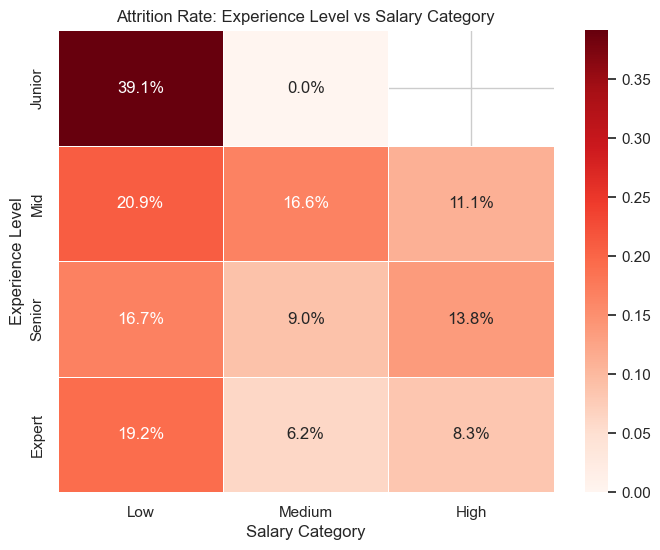

In [6]:
# Calculate Attrition Rate (Target_Attrition must be numerical 0/1)
df['Attrition_Num'] = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

# Create a pivot table for the Heatmap
pivot_table = df.pivot_table(values='Attrition_Num', 
                             index='ExperienceLevel', 
                             columns='SalaryCategory', 
                             aggfunc='mean')

# Plotting the Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_table, annot=True, fmt=".1%", cmap="Reds", linewidths=0.5)
plt.title("Attrition Rate: Experience Level vs Salary Category")
plt.ylabel("Experience Level")
plt.xlabel("Salary Category")
plt.show()

# Drop the temporary numerical target column as we will encode everything properly later
df.drop(columns=['Attrition_Num'], inplace=True)

## 🕸️ 3.7 Employee Profiling (Radar Chart)
Let's compare the psychological and environmental profile of employees who left vs those who stayed using a Radar Chart.

In [7]:
import plotly.graph_objects as go

# 1. Select survey metrics (Scale 1 to 4)
metrics = ['JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance', 'JobInvolvement', 'RelationshipSatisfaction']

# 2. Calculate averages for those who Stayed (No) and Left (Yes)
avg_stay = df[df['Attrition'] == 'No'][metrics].mean().values.tolist()
avg_leave = df[df['Attrition'] == 'Yes'][metrics].mean().values.tolist()

# 3. Close the loop for the radar chart
avg_stay += [avg_stay[0]]
avg_leave += [avg_leave[0]]
metrics_plot = metrics + [metrics[0]]

# 4. Plot the Radar Chart
fig = go.Figure()

fig.add_trace(go.Scatterpolar(
      r=avg_stay, theta=metrics_plot, fill='toself', name='Stayed (No)', line_color='blue'
))
fig.add_trace(go.Scatterpolar(
      r=avg_leave, theta=metrics_plot, fill='toself', name='Left (Yes)', line_color='red'
))

fig.update_layout(
  polar=dict(radialaxis=dict(visible=True, range=[1, 4])), # Scale is 1 to 4
  showlegend=True,
  title="Psychological Profile: Leavers vs Stayers"
)
fig.show()

## 🤖 3.8 Unsupervised Learning: Clustering the "Leavers"
Not all employees leave for the same reason. Let's use **K-Means Clustering** ONLY on the employees who left, to discover the "Personas" of attrition.

--- The 3 Personas of Employees Who Leave ---


,Age,MonthlyIncome,DistanceFromHome,YearsAtCompany,Count
Cluster,,,,,
0,28.2,2879.0,8.1,2.9,138
1,47.3,14412.4,6.1,22.7,14
2,40.2,6299.5,15.5,5.8,85


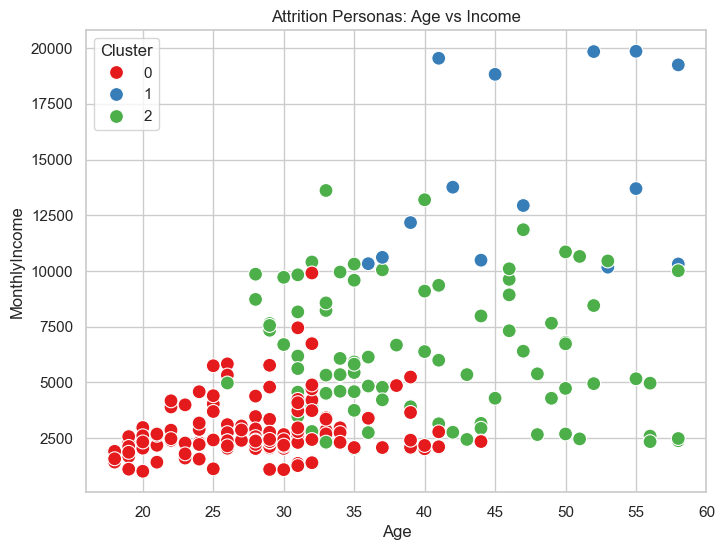

In [8]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Filter only employees who left
leavers_df = df[df['Attrition'] == 'Yes'].copy()

# 2. Select features for clustering
cluster_features = ['Age', 'MonthlyIncome', 'DistanceFromHome', 'YearsAtCompany']
X_cluster = leavers_df[cluster_features]

# 3. Scale the data (K-Means is distance-based)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# 4. Apply K-Means (Let's find 3 personas)
kmeans = KMeans(n_clusters=3, random_state=42)
leavers_df['Cluster'] = kmeans.fit_predict(X_scaled)

# 5. Analyze the Clusters
cluster_summary = leavers_df.groupby('Cluster')[cluster_features].mean().round(1)
cluster_summary['Count'] = leavers_df['Cluster'].value_counts()

print("--- The 3 Personas of Employees Who Leave ---")
display(cluster_summary)

# Visualizing the clusters (Age vs Income)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=leavers_df, x='Age', y='MonthlyIncome', hue='Cluster', palette='Set1', s=100)
plt.title('Attrition Personas: Age vs Income')
plt.show()

## 🎯 4. Data Preparation & Feature Selection (RFE)
Before modeling, we must encode all text columns into numbers. Then, we use Recursive Feature Elimination (RFE) to pick the Top 15 most important features.

In [9]:
# 1. Encode Categorical Data
df_encoded = pd.get_dummies(df, drop_first=True)

# Rename Target Column for ease of use
if 'Attrition_Yes' in df_encoded.columns:
    df_encoded.rename(columns={'Attrition_Yes': 'Target_Attrition'}, inplace=True)

# 2. Separate Features (X) and Target (y)
X = df_encoded.drop(columns=['Target_Attrition'])
y = df_encoded['Target_Attrition']

# 3. Apply RFE using Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rfe = RFE(estimator=rf, n_features_to_select=15, step=1)
rfe.fit(X, y)

# 4. Extract Top Features
selected_features = X.columns[rfe.support_]
print("🌟 Top 15 Features Selected by the AI:")
for idx, feature in enumerate(selected_features, 1):
    print(f"{idx}. {feature}")

# 5. Create final dataset with only the best features
df_final = df_encoded[selected_features.tolist() + ['Target_Attrition']]

🌟 Top 15 Features Selected by the AI:
1. Age
2. DailyRate
3. DistanceFromHome
4. HourlyRate
5. MonthlyIncome
6. MonthlyRate
7. NumCompaniesWorked
8. PercentSalaryHike
9. TotalWorkingYears
10. YearsAtCompany
11. AnnualIncome
12. IncomePerYearExp
13. Age_Company_Ratio
14. Role_Stability
15. OverTime_Yes


## 📊 4.1 Visualizing the Top Selected Features
Let's visualize the relative importance of the features selected by our Random Forest algorithm.

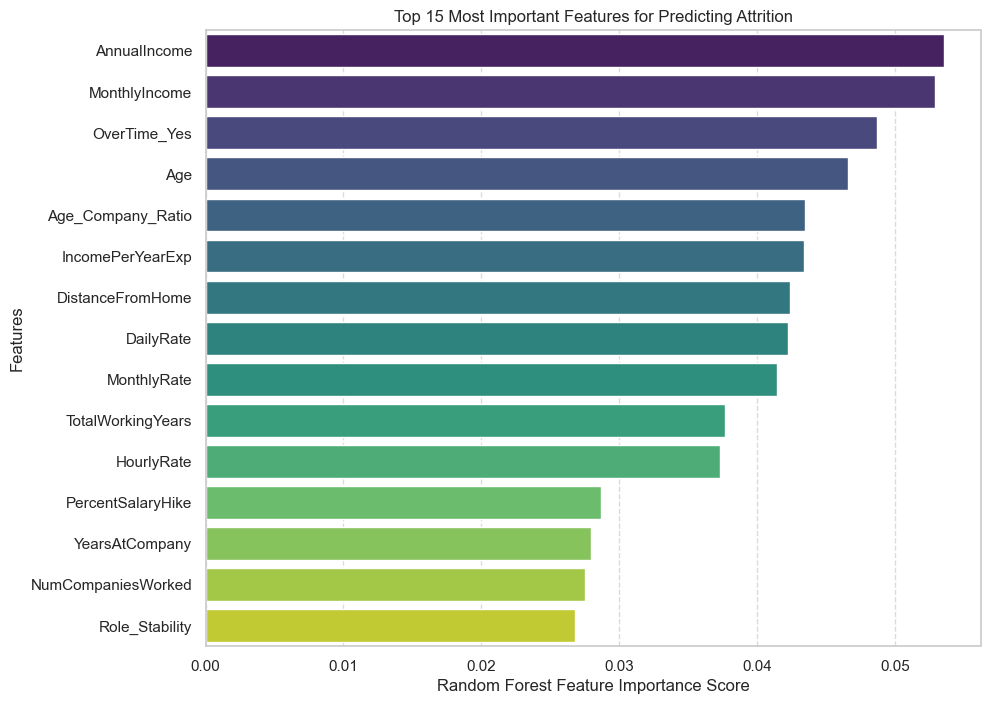

In [10]:
# Train the Random Forest on all data first
rf.fit(X, y)
# Get feature importances from the Random Forest model used in RFE
importances = rf.feature_importances_

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

# Sort by importance and pick the top 15 (which match our RFE selection)
top_features_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(15)

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(data=top_features_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Most Important Features for Predicting Attrition')
plt.xlabel('Random Forest Feature Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## 💾 3. Save Final Features Dataset

In [11]:
# Save this strictly filtered dataset for model training
df_final.to_csv('../data/processed/employee_attrition_selected_features.csv', index=False)
print(f"Dataset with selected features saved! Final Shape: {df_final.shape}")

Dataset with selected features saved! Final Shape: (1470, 16)
